In [14]:
import pandas as pd
df = pd.read_csv('../data/retail_sales_dataset.csv')

df.shape


(1000, 9)

In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [16]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [17]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


Total Amount has a std of 560 vs a mean of 456 — a ratio of 1.23 (123%), which is very high. This means spending is highly variable and unpredictable: typical purchases are ~135, but values range from 25 to 2000. Spending is NOT consistent.

In [18]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [19]:
count = df['Gender'].value_counts()
percentage = df['Gender'].value_counts(normalize=True)*100

summary = pd.DataFrame({
    'Count': count,
    'Percentage':percentage
})

print(summary)

        Count  Percentage
Gender                   
Female    510        51.0
Male      490        49.0


In [20]:
counts = df['Product Category'].value_counts()
percentages  = df['Product Category'].value_counts(normalize = True) * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage' : percentages
})

print(summary)

                  Count  Percentage
Product Category                   
Clothing            351        35.1
Electronics         342        34.2
Beauty              307        30.7


### 1. Sales Over Time (Monthly Trend)
Converting Date from text to a real datetime, then summing Total Amount per month to see seasonal patterns.

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(df['Date'].dt.month)['Total Amount'].sum()
monthly_sales

Date
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

### 2. Age Distribution
A histogram with 20 bins shows how customers are spread across ages.

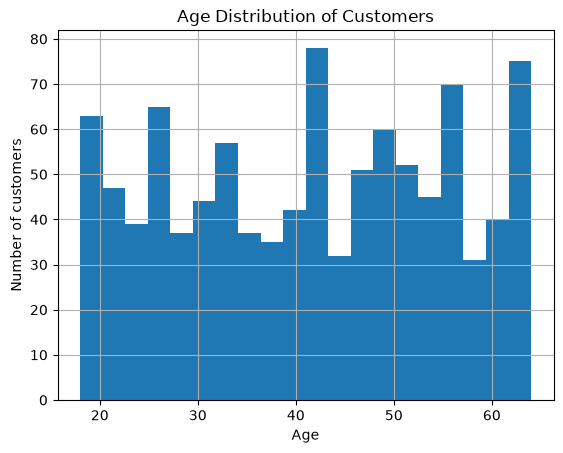

In [22]:
import matplotlib.pyplot as plt
df['Age'].hist(bins=20)
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.title('Age Distribution of Customers')
plt.show()

### 3. Correlation Heatmap
How strongly do the numeric columns move together? (1 = perfect match, 0 = no link, -1 = opposite).

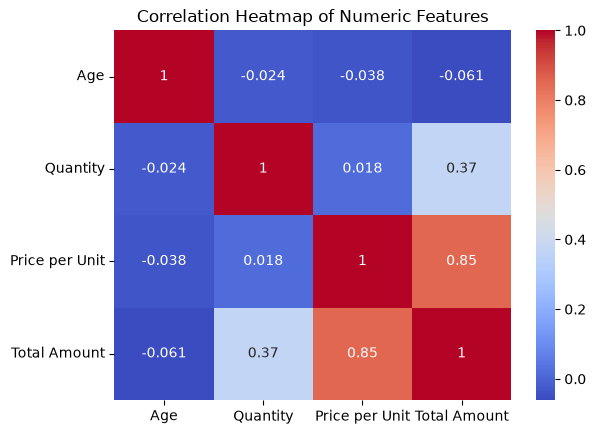

In [23]:
import seaborn as sns
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### 4. Revenue by Category
Which category generates the most total revenue?

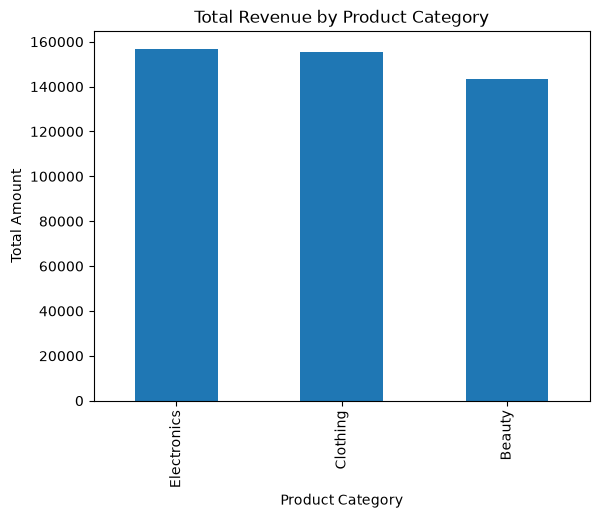

In [24]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar')
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Amount')
plt.show()